## Regression - house price dataset

In [3]:
import pandas as pd
import numpy as np

# read data
data = pd.read_csv("house_price_regression_dataset.csv")
data.shape

(1000, 8)

In [4]:
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [5]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [6]:
# X->features & y->labels
X = data.drop("House_Price", axis=1)
y = data["House_Price"]

In [7]:
from sklearn.model_selection import train_test_split

# creating training, validation & test dataset
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_temp size: ", X_temp.shape)
print("X_test size: ", X_test.shape)
print("y_temp size: ", y_temp.shape)
print("y_test size: ", y_test.shape)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
print("X_train size: ", X_train.shape)
print("y_train size: ", y_train.shape)
print("X_val size: ", X_val.shape)
print("y_val size: ", y_val.shape)



X_temp size:  (800, 7)
X_test size:  (200, 7)
y_temp size:  (800,)
y_test size:  (200,)
X_train size:  (640, 7)
y_train size:  (640,)
X_val size:  (160, 7)
y_val size:  (160,)


In [8]:
from sklearn.preprocessing import StandardScaler

# Normalizing X & y
X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)
X_val = X_scaler.transform(X_val)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))
y_val = y_scaler.transform(y_val.values.reshape(-1,1))

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [9]:
# early stop: training stops when val_loss increases for 5 epoch
early_stop =keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5, 
    restore_best_weights=True
)

In [10]:
# Save best model
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "best_model_trained",         
    monitor="val_loss",       
    save_best_only=True,      
    mode="min",               
    verbose=1
)

In [11]:
import tensorboard
print("TensorBoard is installed!")

TensorBoard is installed!


In [12]:
# creates unique folder for each training run

import os
from datetime import datetime

root_logdir = os.path.join(os.curdir, "my_logs") 

# generate a subdirectory path based on the current date
# and time so that it’s different at every run

def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S") 
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
run_logdir

'./my_logs/run_2026_04_20-11_57_41'

In [14]:
# resets/clears entire Keras/Tensorflow backend state
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# creates NN with Sequential API
model = keras.Sequential()
model.add(keras.layers.Dense(32, activation="relu", input_shape=X_train.shape[1:]))
model.add(keras.layers.Dense(16, activation="relu"))
model.add(keras.layers.Dense(1))

In [15]:
# controls how weights get updated during training
optimize = keras.optimizers.SGD(learning_rate=0.01)

# prepare the model for training
# It tells Keras: What to minimize → loss, How to update weights → optimizer & What to report → metrics
model.compile(loss="mse", optimizer=optimize, metrics=["mae"])


In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                256       
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 801
Trainable params: 801
Non-trainable params: 0
_________________________________________________________________


In [17]:
# save logs in run_logdir file
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

In [18]:
# Training
history = model.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_val, y_val),
    callbacks = [early_stop, checkpoint_cb, tensorboard_cb],
    batch_size=32
)

Epoch 1/100
20/20 [==============================] - 1s 15ms/step - loss: 0.9561 - mae: 0.8333 - val_loss: 0.7991 - val_mae: 0.7636

Epoch 00001: val_loss improved from inf to 0.79908, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 2/100
20/20 [==============================] - 0s 3ms/step - loss: 0.6412 - mae: 0.6765 - val_loss: 0.5232 - val_mae: 0.6131

Epoch 00002: val_loss improved from 0.79908 to 0.52321, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 3/100
20/20 [==============================] - 0s 3ms/step - loss: 0.4043 - mae: 0.5243 - val_loss: 0.2964 - val_mae: 0.4531

Epoch 00003: val_loss improved from 0.52321 to 0.29645, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 4/100
20/20 [==============================] - 0s 3ms/step - loss: 0.2307 - mae: 0.3827 - val_loss: 0.1658 - val_mae: 0.3277

Epoch 00004: val_lo

INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 31/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0142 - mae: 0.0957 - val_loss: 0.0193 - val_mae: 0.1080

Epoch 00031: val_loss improved from 0.01932 to 0.01926, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 32/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0139 - mae: 0.0948 - val_loss: 0.0193 - val_mae: 0.1081

Epoch 00032: val_loss did not improve from 0.01926
Epoch 33/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0137 - mae: 0.0939 - val_loss: 0.0191 - val_mae: 0.1074

Epoch 00033: val_loss improved from 0.01926 to 0.01910, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 34/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0135 - mae: 0.0935 - val_loss: 0.0186 - val_mae: 0.1063

Epoch 00034: val_loss improved from 0.01910 to 0.018


Epoch 00063: val_loss did not improve from 0.01539
Epoch 64/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0100 - mae: 0.0803 - val_loss: 0.0156 - val_mae: 0.0968

Epoch 00064: val_loss did not improve from 0.01539
Epoch 65/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0099 - mae: 0.0803 - val_loss: 0.0155 - val_mae: 0.0967

Epoch 00065: val_loss did not improve from 0.01539


In [19]:

!ls my_logs/run_2026_04_20-11_57_41/train

events.out.tfevents.1776686312.cxln4.2516.0.v2	    plugins
events.out.tfevents.1776686312.cxln4.profile-empty


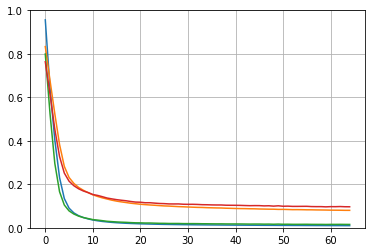

In [20]:
import matplotlib.pyplot as plt

plt.plot(pd.DataFrame(history.history))
plt.grid(True)
plt.gca().set_ylim(0, 1) # setting y-axis limit
plt.show()

In [21]:
# evaluate trained model on unseen test dataset
model.evaluate(X_test, y_test)


import numpy as np

best_epoch = np.argmin(history.history["val_loss"]) + 1
print("Best epoch:", best_epoch)

7/7 [==============================] - 0s 2ms/step - loss: 0.0157 - mae: 0.1020
Best epoch: 60


In [22]:
best_model = keras.models.load_model("best_model_trained")
best_model.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.0157 - mae: 0.1020


[0.01568559929728508, 0.10196579247713089]

In [23]:
# reverting normalized data to get real world error 

preds = model.predict(X_test)

preds = y_scaler.inverse_transform(preds)
y_test_actual = y_scaler.inverse_transform(y_test)

mae_real = np.mean(np.abs(y_test_actual - preds))
print("Real MAE:", mae_real)

Real MAE: 25596.28036841895


In [24]:
baseline_pred = y_train.mean()
mae_baseline = np.mean(np.abs(y_test - baseline_pred))
print((baseline_pred, mae_baseline))

(1.1102230246251565e-16, 0.8743825199598365)


In [25]:

baseline_preds = np.full(shape=len(y_test), fill_value=baseline_pred)

baseline_mae = np.mean(np.abs(y_test - baseline_preds))
print("Baseline MAE:", baseline_mae)

model_preds = model.predict(X_test)

# If you scaled y, don't forget inverse transform
model_preds = y_scaler.inverse_transform(model_preds)
y_test_actual = y_scaler.inverse_transform(y_test)

model_mae = np.mean(np.abs(y_test_actual - model_preds))
print("Model MAE:", model_mae)


improvement = baseline_mae - model_mae
print("Improvement:", improvement)

Baseline MAE: 0.8743825199598365
Model MAE: 25596.28036841895
Improvement: -25595.40598589899


## Class Model

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
import os
from datetime import datetime
import matplotlib.pyplot as plt

import time


class HousePriceModel:
    def __init__(self):
        self.X_scaler = StandardScaler()
        self.y_scaler = StandardScaler()
        self.model=None
        
        self.root_logdir = os.path.join(os.curdir, "my_logs")
        self.run_logdir = self.get_run_logdir()
        
    # Create unique log directory
    def get_run_logdir(self):
        run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S") 
        return os.path.join(self.root_logdir, run_id)

   # load data - "house_price_regression_dataset.csv"
    def load_data(self, path):
        data = pd.read_csv(path)
        
        X = data.drop("House_Price", axis=1)
        y = data["House_Price"]
        
        X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

        return X_train, X_val, X_test, y_train, y_val, y_test

    # preprocess
    def preprocess(self, X_train, X_val, X_test, y_train, y_val, y_test):
        X_train = self.X_scaler.fit_transform(X_train)
        X_test = self.X_scaler.transform(X_test)
        X_val = self.X_scaler.transform(X_val)
        
        y_train = self.y_scaler.fit_transform(y_train.values.reshape(-1,1))
        y_test = self.y_scaler.transform(y_test.values.reshape(-1,1))
        y_val = self.y_scaler.transform(y_val.values.reshape(-1,1))

        return X_train, X_val, X_test, y_train, y_val, y_test
    
    # Build model
    def build_model(self, inputshape):
        keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)
        
        self.model = keras.Sequential([
            keras.layers.Dense(32, activation="relu", input_shape=inputshape),
            keras.layers.Dense(16, activation="relu"),
            keras.layers.Dense(1)
        ])
        
        optimize = keras.optimizers.SGD(learning_rate=0.01)
        
        self.model.compile(
            loss="mse", 
            optimizer=optimize, 
            metrics=["mae"]
        )
        
    # Train model
    def train(self, X_train, X_val, y_train, y_val):
        early_stop =keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5, 
            restore_best_weights=True
        )

        checkpoint_cb = keras.callbacks.ModelCheckpoint(
            "best_model_trained",         
            monitor="val_loss",       
            save_best_only=True,      
            mode="min",               
            verbose=1
        )

        tensorboard_cb = keras.callbacks.TensorBoard(
            log_dir=self.run_logdir
        )

        history = self.model.fit(
            X_train, y_train, 
            epochs=100, 
            validation_data=(X_val, y_val),
            callbacks = [early_stop, checkpoint_cb, tensorboard_cb],
            batch_size=32
        )
    
        return history

    # plot training history
    def plot_history(self, history):
        plt.plot(pd.DataFrame(history.history))
        plt.grid(True)
        plt.gca().set_ylim(0, 1) # setting y-axis limit
        plt.show()

    # Evaluate model
    def evaluate(self, X_test, y_test):
        return self.model.evaluate(X_test, y_test)
    
    # Predict (inverse scaling)
    def predict(self, X):
        preds = self.model.predict(X)
        return self.y_scaler.inverse_transform(preds)
    
    def y_test_values(self, y):
        return self.y_scaler.inverse_transform(y) 


Epoch 1/100
20/20 [==============================] - 1s 13ms/step - loss: 0.9561 - mae: 0.8333 - val_loss: 0.7991 - val_mae: 0.7636

Epoch 00001: val_loss improved from inf to 0.79908, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 2/100
20/20 [==============================] - 0s 2ms/step - loss: 0.6412 - mae: 0.6765 - val_loss: 0.5232 - val_mae: 0.6131

Epoch 00002: val_loss improved from 0.79908 to 0.52321, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 3/100
20/20 [==============================] - 0s 3ms/step - loss: 0.4043 - mae: 0.5243 - val_loss: 0.2964 - val_mae: 0.4531

Epoch 00003: val_loss improved from 0.52321 to 0.29645, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 4/100
20/20 [==============================] - 0s 3ms/step - loss: 0.2307 - mae: 0.3827 - val_loss: 0.1658 - val_mae: 0.3277

Epoch 00004: val_lo

INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 31/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0142 - mae: 0.0957 - val_loss: 0.0193 - val_mae: 0.1080

Epoch 00031: val_loss improved from 0.01932 to 0.01926, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 32/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0139 - mae: 0.0948 - val_loss: 0.0193 - val_mae: 0.1081

Epoch 00032: val_loss did not improve from 0.01926
Epoch 33/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0137 - mae: 0.0939 - val_loss: 0.0191 - val_mae: 0.1074

Epoch 00033: val_loss improved from 0.01926 to 0.01910, saving model to best_model_trained
INFO:tensorflow:Assets written to: best_model_trained/assets
Epoch 34/100
20/20 [==============================] - 0s 2ms/step - loss: 0.0135 - mae: 0.0935 - val_loss: 0.0186 - val_mae: 0.1063

Epoch 00034: val_loss improved from 0.01910 to 0.018


Epoch 00063: val_loss did not improve from 0.01539
Epoch 64/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0100 - mae: 0.0803 - val_loss: 0.0156 - val_mae: 0.0968

Epoch 00064: val_loss did not improve from 0.01539
Epoch 65/100
20/20 [==============================] - 0s 3ms/step - loss: 0.0099 - mae: 0.0803 - val_loss: 0.0155 - val_mae: 0.0967

Epoch 00065: val_loss did not improve from 0.01539


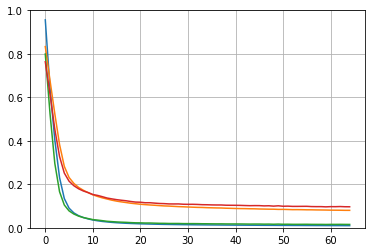

7/7 [==============================] - 0s 2ms/step - loss: 0.0157 - mae: 0.1020


[0.01568559929728508, 0.10196579247713089]

In [27]:
# How to Use Model Class

model_obj = HousePriceModel()

# Load data
X_train, X_val, X_test, y_train, y_val, y_test = model_obj.load_data("house_price_regression_dataset.csv")

# Preprocess
X_train, X_val, X_test, y_train, y_val, y_test = model_obj.preprocess(X_train, X_val, X_test, y_train, y_val, y_test)

# Build model
model_obj.build_model(inputshape=X_train.shape[1:])

# Train
history = model_obj.train(X_train, X_val, y_train, y_val)

model_obj.plot_history(history)

model_obj.evaluate(X_test, y_test)

In [28]:
print(model_obj.predict(X_test))

[[ 871604.9 ]
 [ 473386.8 ]
 [ 956656.06]
 [1015017.8 ]
 [ 810267.5 ]
 [ 749878.94]
 [ 983553.25]
 [ 885560.1 ]
 [ 844244.  ]
 [ 930778.6 ]
 [ 771822.7 ]
 [ 658946.1 ]
 [ 252093.08]
 [1017917.1 ]
 [ 551667.5 ]
 [ 147482.67]
 [ 483644.12]
 [ 340495.4 ]
 [ 759065.1 ]
 [ 368161.5 ]
 [ 784385.75]
 [ 495483.12]
 [ 653134.1 ]
 [ 924602.  ]
 [ 444438.2 ]
 [ 387324.66]
 [ 436760.44]
 [ 480233.88]
 [ 194774.05]
 [ 410503.3 ]
 [ 275996.03]
 [ 880471.2 ]
 [ 811747.94]
 [ 355800.78]
 [ 486427.72]
 [ 783604.25]
 [ 485691.78]
 [ 548576.6 ]
 [ 283667.22]
 [ 192685.73]
 [ 237800.45]
 [ 296580.25]
 [ 519079.62]
 [ 306413.66]
 [1052601.  ]
 [1024819.1 ]
 [ 708335.44]
 [ 816581.6 ]
 [1016782.56]
 [ 669170.9 ]
 [ 271013.84]
 [ 734998.1 ]
 [ 845661.  ]
 [ 732963.9 ]
 [ 484153.53]
 [ 785071.06]
 [ 239661.33]
 [ 334196.53]
 [ 734725.6 ]
 [ 248095.64]
 [ 977237.6 ]
 [ 381760.06]
 [ 369302.22]
 [ 452196.5 ]
 [ 605654.6 ]
 [ 549127.9 ]
 [ 435001.7 ]
 [ 771370.56]
 [ 921862.75]
 [ 730392.3 ]
 [ 452642.1 ]
 [ 860

In [29]:
print(model_obj.y_test_values(y_test))

[[ 901000.48823382]
 [ 494537.5115455 ]
 [ 949404.20066573]
 [1040389.04813578]
 [ 794010.01673364]
 [ 724033.56045713]
 [ 998439.23711398]
 [ 909713.4350007 ]
 [ 792681.51842008]
 [ 947490.77747782]
 [ 774150.04681239]
 [ 654466.94540868]
 [ 217462.44505709]
 [1034380.20416167]
 [ 530476.12327498]
 [ 194353.73613998]
 [ 441315.08847494]
 [ 354744.63059531]
 [ 755402.37269125]
 [ 348893.55395287]
 [ 763645.6101594 ]
 [ 475767.3504504 ]
 [ 676108.85120969]
 [ 887527.90717999]
 [ 438250.17615462]
 [ 402213.42189319]
 [ 472657.61431723]
 [ 453579.10553422]
 [ 191907.65250489]
 [ 489595.41246134]
 [ 270230.63769828]
 [ 893926.62947207]
 [ 771922.84982131]
 [ 338350.59543444]
 [ 457643.09804238]
 [ 775773.2237663 ]
 [ 474659.86005528]
 [ 570399.74276779]
 [ 280961.68038979]
 [ 147601.55157708]
 [ 300656.0790682 ]
 [ 307101.68583856]
 [ 486872.05670913]
 [ 304653.63604893]
 [1092026.89678641]
 [1008539.15623435]
 [ 747938.71154396]
 [ 818613.71080341]
 [1028282.31182189]
 [ 694917.30087455]


In [ ]:
# export PATH=/usr/local/anaconda/bin:$PATH
# tensorboard --logdir=./my_logs --port=4040 --bind_all